In [ ]:
import zipfile
import os

zip_normal = 'normal.zip'
zip_distorted = 'divided_distortion.zip'


with zipfile.ZipFile(f'/content/{zip_normal}', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_normal')

with zipfile.ZipFile(f'/content/{zip_distorted}', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_distorted')


In [ ]:
import os

# Define the path to the directory containing all distortion sub-folders
distorted_base_path = "/content/dataset_distorted"

print("--- Image Count per Distortion Type ---")
total_distorted_count = 0

# Verify the path exists before scanning
if os.path.exists(distorted_base_path):
    # Iterate through each item in the base directory
    for folder_name in sorted(os.listdir(distorted_base_path)):
        folder_path = os.path.join(distorted_base_path, folder_name)

        # Check if the item is a directory
        if os.path.isdir(folder_path):
            # Count image files with common extensions
            image_list = [f for f in os.listdir(folder_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            folder_count = len(image_list)
            print(f"Distortion: '{folder_name}' -> Count: {folder_count}")
            total_distorted_count += folder_count

    print("-" * 40)
    print(f"Total Distorted Images: {total_distorted_count}")
else:
    print(f"Error: Path '{distorted_base_path}' does not exist.")

--- Image Count per Distortion Type ---
Distortion: 'Broken Line' -> Count: 4157
Distortion: 'Corner' -> Count: 256
Distortion: 'Edge False Color' -> Count: 4035
Distortion: 'Line Noise' -> Count: 136
Distortion: 'Moire' -> Count: 762
Distortion: 'Over Desaturation' -> Count: 2673
Distortion: 'Pattern artifact' -> Count: 15
Distortion: 'Saturated False Color' -> Count: 1405
Distortion: 'Smears' -> Count: 2732
Distortion: 'Zagging' -> Count: 219
----------------------------------------
Total Distorted Images: 16390


In [ ]:
import os
import shutil

# 1. Configuration
distorted_base_path = "/content/dataset_distorted"
normal_base_path = "/content/dataset_normal"

# List of folders to keep in the distorted directory
allowed_distortions = [
    "Broken Line",
    "Edge False Color",
    "Over Desaturation",
    "Saturated False Color",
    "Smears"
]

# Limits
DISTORTED_LIMIT = 1405
NORMAL_LIMIT = 7025

def cleanup_and_limit_dataset():
    # --- Part 1: Handle Distorted Folders ---
    print("Processing Distorted Folders...")
    if os.path.exists(distorted_base_path):
        for folder_name in os.listdir(distorted_base_path):
            folder_path = os.path.join(distorted_base_path, folder_name)

            if os.path.isdir(folder_path):
                # Delete folder if not in the allowed list
                if folder_name not in allowed_distortions:
                    print(f"Deleting unwanted folder: {folder_name}")
                    shutil.rmtree(folder_path)
                else:
                    # Limit the number of images in the allowed folder
                    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    if len(files) > DISTORTED_LIMIT:
                        print(f"Limiting '{folder_name}' to {DISTORTED_LIMIT} images...")
                        files_to_delete = files[DISTORTED_LIMIT:]
                        for f in files_to_delete:
                            os.remove(os.path.join(folder_path, f))

    # --- Part 2: Handle Normal Folder ---
    print("\nProcessing Normal Folder...")
    if os.path.exists(normal_base_path):
        # Note: Based on your previous output, images are directly in this folder
        files = sorted([f for f in os.listdir(normal_base_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        if len(files) > NORMAL_LIMIT:
            print(f"Limiting Normal folder to {NORMAL_LIMIT} images...")
            files_to_delete = files[NORMAL_LIMIT:]
            for f in files_to_delete:
                os.remove(os.path.join(normal_base_path, f))
        else:
            print(f"Normal folder has {len(files)} images (under the limit).")

    print("\nCleanup finished successfully!")

# Run the cleanup
cleanup_and_limit_dataset()

Processing Distorted Folders...
Limiting 'Broken Line' to 1405 images...
Deleting unwanted folder: Moire
Limiting 'Smears' to 1405 images...
Limiting 'Over Desaturation' to 1405 images...
Deleting unwanted folder: Corner
Deleting unwanted folder: Line Noise
Deleting unwanted folder: Pattern artifact
Limiting 'Edge False Color' to 1405 images...
Deleting unwanted folder: Zagging

Processing Normal Folder...
Normal folder has 7025 images (under the limit).

Cleanup finished successfully!


--- Dataset Summary ---
Total images: 14050
Normal samples: 7025
Distorted samples: 7025
Using device: cuda


Epoch 1/50: 100%|██████████| 352/352 [00:07<00:00, 46.87it/s, loss=0.317]


Epoch 1 Summary: Test Acc: 0.9093


Epoch 2/50: 100%|██████████| 352/352 [00:07<00:00, 48.15it/s, loss=0.216]


Epoch 2 Summary: Test Acc: 0.9338


...

Epoch 21 Summary: Test Acc: 0.9847


Epoch 22/50: 100%|██████████| 352/352 [00:07<00:00, 44.52it/s, loss=0.0351]


Epoch 22 Summary: Test Acc: 0.9815


Epoch 23/50: 100%|██████████| 352/352 [00:09<00:00, 35.55it/s, loss=0.0242]


Epoch 23 Summary: Test Acc: 0.9840
Early stopping triggered.


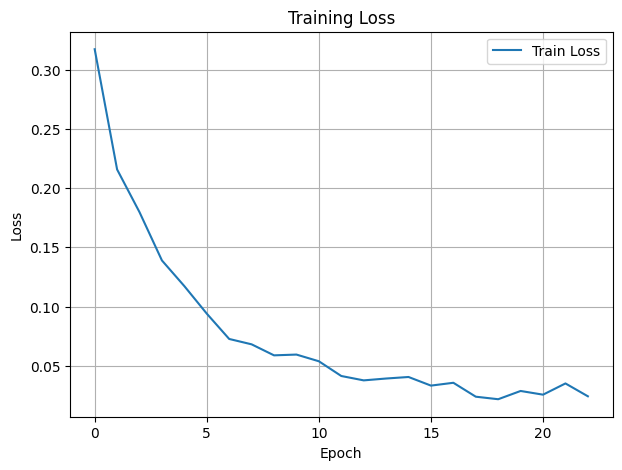

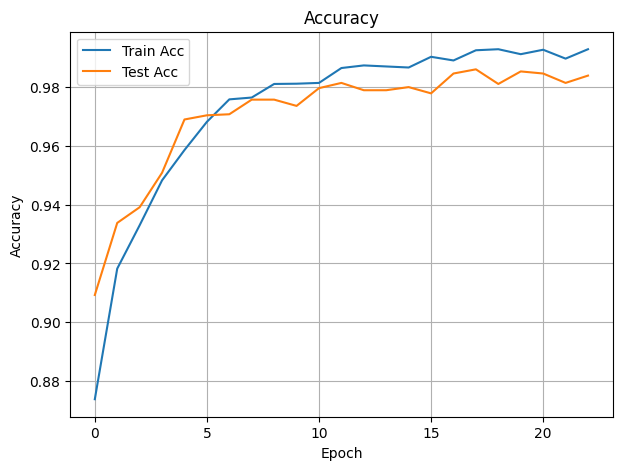

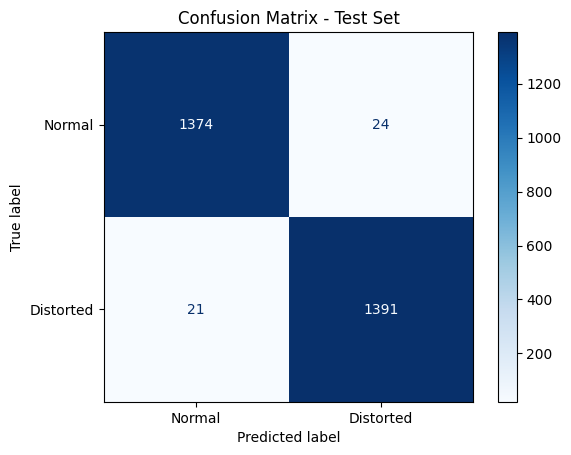

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1398
   Distorted       0.98      0.99      0.98      1412

    accuracy                           0.98      2810
   macro avg       0.98      0.98      0.98      2810
weighted avg       0.98      0.98      0.98      2810



In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ==========================================
# 1. Path Definitions
# ==========================================
data_base_path = "/home/inonzr/datasets/samsung"
normal_dir = "/content/dataset_normal"
distorted_dir = "/content/dataset_distorted"

# ==========================================
# 2. Dataset Definition
# ==========================================
class LocalBinaryDataset(Dataset):
    def __init__(self, normal_path, distorted_path, transform=None):
        self.samples = []
        self.transform = transform

        if os.path.exists(normal_path):
            for root, _, files in os.walk(normal_path):
                for f in files:
                    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((os.path.join(root, f), 0))

        if os.path.exists(distorted_path):
            for root, _, files in os.walk(distorted_path):
                for f in files:
                    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((os.path.join(root, f), 1))

        num_normal = sum(1 for _, label in self.samples if label == 0)
        num_distorted = sum(1 for _, label in self.samples if label == 1)

        print(f"--- Dataset Summary ---")
        print(f"Total images: {len(self.samples)}")
        print(f"Normal samples: {num_normal}")
        print(f"Distorted samples: {num_distorted}")

        if len(self.samples) == 0:
            print("WARNING: No images found! Check your paths.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# ==========================================
# 3. Data Loader Preparation
# ==========================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = LocalBinaryDataset(normal_dir, distorted_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_ds, test_ds = random_split(full_dataset, [train_size, test_size])

# GPU OPTIMIZATION ADDED HERE (num_workers and pin_memory)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# ==========================================
# 4. Model Architecture
# ==========================================
class ArtifactCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.classifier(self.features(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") # Prints whether you are actually using the GPU

model = ArtifactCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# ==========================================
# 5. Training Loop with Logging for Graphs
# ==========================================
epochs = 50
best_acc = 0
patience = 5
counter = 0

train_losses, train_accs, test_accs = [], [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for imgs, labels in loop:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True) # Optimized transfer
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (pred == labels).sum().item()
        loop.set_postfix(loss=running_loss/len(train_loader))

    train_losses.append(running_loss/len(train_loader))
    train_accs.append(correct_train/total_train)

    model.eval()
    correct_test = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(imgs)
            _, pred = torch.max(outputs, 1)
            correct_test += (pred == labels).sum().item()

    accuracy = correct_test / len(test_ds)
    test_accs.append(accuracy)
    print(f"Epoch {epoch+1} Summary: Test Acc: {accuracy:.4f}")

    if accuracy > best_acc:
        best_acc = accuracy
        torch.save(model.state_dict(), "best_binary_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# ==========================================
# 6. Graphs + Confusion Matrix
# ==========================================
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

all_labels, all_preds = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        outputs = model(imgs)
        _, pred = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Distorted"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

print(classification_report(all_labels, all_preds, target_names=["Normal", "Distorted"]))

Generating Error Analysis Heatmap...


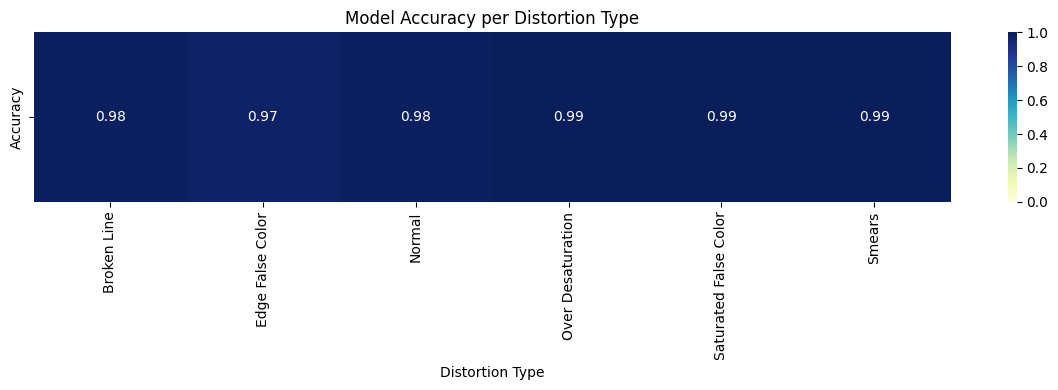

In [ ]:
# ==========================================
#  Error Analysis: Heatmap per Distortion
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_error_analysis(model, loader):
    model.eval()
    analysis_data = []

    # Access the base dataset and the indices properly
    # If it's a Subset (from random_split), we get the underlying dataset
    if hasattr(loader.dataset, 'dataset'):
        full_dataset = loader.dataset.dataset
        indices = loader.dataset.indices
    else:
        full_dataset = loader.dataset
        indices = range(len(full_dataset))

    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(loader):
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            # Find which images from the original dataset are in this batch
            start_idx = batch_idx * loader.batch_size
            batch_indices = indices[start_idx : start_idx + len(labels)]

            for i, idx in enumerate(batch_indices):
                # Get the file path from the samples list
                img_path, _ = full_dataset.samples[idx]
                dist_type = img_path.split('/')[-2]

                if dist_type == "dataset_normal" or dist_type == "Normal":
                    dist_type = "Normal"

                is_correct = 1 if preds[i] == labels[i] else 0
                analysis_data.append({"Distortion Type": dist_type, "Accuracy": is_correct})

    if not analysis_data:
        print("No data collected for analysis. Check if the loader is empty.")
        return

    df = pd.DataFrame(analysis_data)
    pivot = df.groupby("Distortion Type")["Accuracy"].mean().reset_index()

    plt.figure(figsize=(12, 4))
    sns.heatmap(pivot.set_index("Distortion Type").T, annot=True, cmap="YlGnBu", fmt=".2f", vmin=0, vmax=1)
    plt.title("Model Accuracy per Distortion Type")
    plt.tight_layout()
    plt.show()

print("Generating Error Analysis Heatmap...")
run_error_analysis(model, test_loader)

In [ ]:
# ==========================================
#  Bootstrapping for Confidence Intervals
# ==========================================
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils import resample

def perform_bootstrapping(model, loader, n_iterations=1000, alpha=0.95):
    model.eval()
    all_preds = []
    all_true = []

    # Collect all predictions from the test set
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    all_true = np.array(all_true)
    all_preds = np.array(all_preds)

    print(f"Starting Bootstrapping with {n_iterations} iterations...")
    bootstrapped_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

    for i in range(n_iterations):
        # Sampling with replacement
        indices = resample(np.arange(len(all_true)), replace=True)
        sampled_true = all_true[indices]
        sampled_preds = all_preds[indices]

        acc = accuracy_score(sampled_true, sampled_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(
            sampled_true, sampled_preds, average='macro', zero_division=0)

        bootstrapped_metrics['accuracy'].append(acc)
        bootstrapped_metrics['precision'].append(prec)
        bootstrapped_metrics['recall'].append(rec)
        bootstrapped_metrics['f1'].append(f1)

    print(f"\n--- Bootstrapping Results ({alpha*100}% Confidence Interval) ---")
    lower_p = ((1.0 - alpha) / 2.0) * 100
    upper_p = (alpha + ((1.0 - alpha) / 2.0)) * 100

    for metric_name, values in bootstrapped_metrics.items():
        mean_val = np.mean(values)
        lower_bound = np.percentile(values, lower_p)
        upper_bound = np.percentile(values, upper_p)
        print(f"{metric_name.capitalize():<10} | Mean: {mean_val:.4f} | CI: [{lower_bound:.4f}, {upper_bound:.4f}]")

# Execute Bootstrapping on the original test_loader
perform_bootstrapping(model, test_loader)

Starting Bootstrapping with 1000 iterations...

--- Bootstrapping Results (95.0% Confidence Interval) ---
Accuracy   | Mean: 0.9840 | CI: [0.9794, 0.9886]
Precision  | Mean: 0.9840 | CI: [0.9793, 0.9886]
Recall     | Mean: 0.9840 | CI: [0.9793, 0.9886]
F1         | Mean: 0.9840 | CI: [0.9793, 0.9886]


Generating ROC Curve and calculating Precision@K...


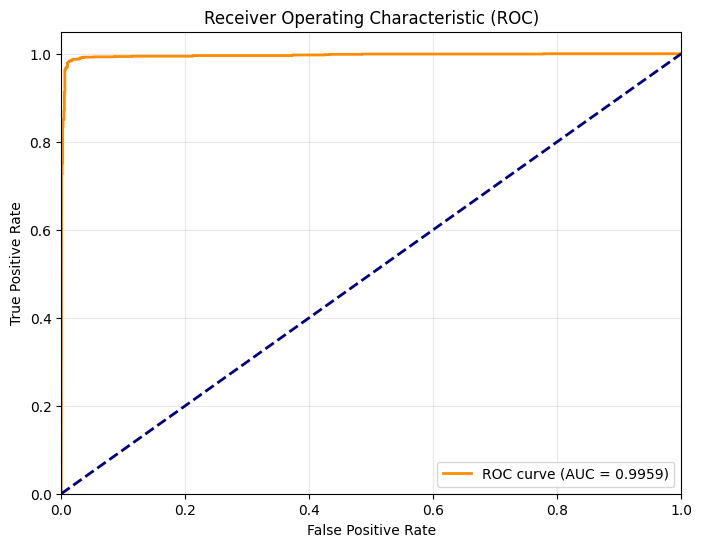


--- Precision@K Results ---
Precision@50 : 1.0000 (50/50 correct)
Precision@100: 1.0000 (100/100 correct)
Precision@200: 1.0000 (200/200 correct)


In [ ]:
# ==========================================
#  Advanced Metrics: ROC Curve, AUC & Precision@K
# ==========================================
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

def run_advanced_metrics(model, loader, k_values=[50, 100, 200]):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            positive_probs = probs[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(positive_probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print("\n--- Precision@K Results ---")
    sorted_indices = np.argsort(all_probs)[::-1]
    sorted_labels = all_labels[sorted_indices]

    for k in k_values:
        if k > len(sorted_labels):
            print(f"Cannot calculate Precision@{k}: K is larger than the test set.")
            continue

        top_k_labels = sorted_labels[:k]
        precision_at_k = np.sum(top_k_labels) / k
        print(f"Precision@{k:<3}: {precision_at_k:.4f} ({np.sum(top_k_labels)}/{k} correct)")

print("Generating ROC Curve and calculating Precision@K...")
run_advanced_metrics(model, test_loader)

In [ ]:
# ==========================================
#  K-Fold Cross Validation & Advanced Metrics
# ==========================================
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

K_FOLDS = 5
epochs = 10
fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
dataset_indices = list(range(len(full_dataset)))

criterion = nn.CrossEntropyLoss()

for fold, (train_ids, test_ids) in enumerate(kf.split(dataset_indices)):
    print(f"\n{'='*15} FOLD {fold + 1}/{K_FOLDS} {'='*15}")

    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    test_subsampler = torch.utils.data.SubsetRandomSampler(test_ids)

    # GPU OPTIMIZATION ADDED HERE
    train_loader = DataLoader(full_dataset, batch_size=32, sampler=train_subsampler, num_workers=2, pin_memory=True)
    test_loader = DataLoader(full_dataset, batch_size=32, sampler=test_subsampler, num_workers=2, pin_memory=True)

    model = ArtifactCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        all_preds = []
        all_true = []

        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(imgs)
                _, pred = torch.max(outputs, 1)

                all_preds.extend(pred.cpu().numpy())
                all_true.extend(labels.cpu().numpy())

        acc = accuracy_score(all_true, all_preds)
        print(f"Fold {fold+1}, Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

    prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, average='macro', zero_division=0)

    fold_metrics['accuracy'].append(acc)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['f1'].append(f1)

    print(f"\n--- Fold {fold+1} Per-Class Analysis ---")
    per_class_prec, per_class_rec, per_class_f1, support = precision_recall_fscore_support(all_true, all_preds, zero_division=0)
    print(f"Normal (Class 0)    - Accuracy/Recall: {per_class_rec[0]:.4f}, Error Rate: {1 - per_class_rec[0]:.4f}")
    print(f"Distorted (Class 1) - Accuracy/Recall: {per_class_rec[1]:.4f}, Error Rate: {1 - per_class_rec[1]:.4f}")

print(f"\n{'='*15} FINAL K-FOLD RESULTS {'='*15}")
for metric_name, values in fold_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"{metric_name.capitalize()}: Mean = {mean_val:.4f}, Std = {std_val:.4f}")


=============== FOLD 1/5 ===============
Fold 1, Epoch 1/10 | Loss: 0.3107 | Test Acc: 0.8883
Fold 1, Epoch 2/10 | Loss: 0.2070 | Test Acc: 0.9317
Fold 1, Epoch 3/10 | Loss: 0.1758 | Test Acc: 0.9395
Fold 1, Epoch 4/10 | Loss: 0.1416 | Test Acc: 0.9605
Fold 1, Epoch 5/10 | Loss: 0.1164 | Test Acc: 0.9626
Fold 1, Epoch 6/10 | Loss: 0.0962 | Test Acc: 0.9676
Fold 1, Epoch 7/10 | Loss: 0.0862 | Test Acc: 0.9769
Fold 1, Epoch 8/10 | Loss: 0.0731 | Test Acc: 0.9730
Fold 1, Epoch 9/10 | Loss: 0.0624 | Test Acc: 0.9765
Fold 1, Epoch 10/10 | Loss: 0.0574 | Test Acc: 0.9601

--- Fold 1 Per-Class Analysis ---
Normal (Class 0)    - Accuracy/Recall: 0.9603, Error Rate: 0.0397
Distorted (Class 1) - Accuracy/Recall: 0.9599, Error Rate: 0.0401

=============== FOLD 2/5 ===============
Fold 2, Epoch 1/10 | Loss: 0.3379 | Test Acc: 0.9149
Fold 2, Epoch 2/10 | Loss: 0.2185 | Test Acc: 0.9345
Fold 2, Epoch 3/10 | Loss: 0.1769 | Test Acc: 0.9370
Fold 2, Epoch 4/10 | Loss: 0.1446 | Test Acc: 0.9520
Fold 2